## **Mengimport Semua Library yang diperlukan**

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## **Loading Data awal & memeriksa Tipe data**

In [90]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'

df = pd.read_csv(url)
display(df)
print("==" * 20)
display(df.info())

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532,TX001046,AC00474,230.08,2023-05-01 16:23:40,Debit,Austin,D000045,93.52.44.101,M006,Online,79.0,Retired,124.0,1.0,4466.10,2024-11-04 8:11:47
2533,TX001484,AC00198,561.58,2023-06-23 17:38:26,Debit,Sacramento,D000229,170.154.69.105,M022,Online,65.0,Doctor,23.0,1.0,11748.86,2024-11-04 8:06:32
2534,TX000200,AC00358,493.11,2023-07-31 16:25:26,Debit,Colorado Springs,D000232,35.220.238.127,M022,Branch,53.0,Retired,236.0,1.0,7432.99,2024-11-04 8:08:01
2535,TX000592,AC00057,198.62,2023-05-15 16:19:14,Credit,Tucson,D000378,97.4.209.133,M079,Branch,27.0,Student,84.0,1.0,1196.07,2024-11-04 8:06:38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

None

## **Menghapus Kolom yang tidak diperlukan**

In [91]:
df_baru= df.drop(columns=['MerchantID', 'LoginAttempts', 'TransactionDate', 'PreviousTransactionDate', 'AccountID', 'IP Address', 'DeviceID'])
display(df_baru)

,TransactionID,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,AccountBalance
0,TX000001,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,5112.21
1,TX000002,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,13758.91
2,TX000003,126.29,Debit,Mesa,Online,19.0,Student,56.0,1122.35
3,TX000004,184.50,Debit,Raleigh,Online,26.0,Student,25.0,8569.06
4,TX000005,13.45,Credit,Atlanta,Online,NaN,Student,198.0,7429.40
...,...,...,...,...,...,...,...,...,...
2532,TX001046,230.08,Debit,Austin,Online,79.0,Retired,124.0,4466.10
2533,TX001484,561.58,Debit,Sacramento,Online,65.0,Doctor,23.0,11748.86
2534,TX000200,493.11,Debit,Colorado Springs,Branch,53.0,Retired,236.0,7432.99
2535,TX000592,198.62,Credit,Tucson,Branch,27.0,Student,84.0,1196.07


## **Mengganti Kolom agar mudah dipahami**

In [92]:
kamus_kolom = {
    'TransactionID': 'ID_Transaksi',
    'TransactionAmount': 'Jumlah_Transaksi',
    'TransactionType': 'Jenis_Transaksi',
    'Channel': 'Kanal_Transaksi',
    'CustomerAge': 'Usia_Nasabah',
    'CustomerOccupation': 'Pekerjaan_Nasabah',
    'TransactionDuration': 'Durasi_Transaksi',
    'AccountBalance': 'Saldo_Akun',
    'Location': 'Lokasi'
}

df_baru.rename(columns=kamus_kolom, inplace=True)
display(df_baru)

,ID_Transaksi,Jumlah_Transaksi,Jenis_Transaksi,Lokasi,Kanal_Transaksi,Usia_Nasabah,Pekerjaan_Nasabah,Durasi_Transaksi,Saldo_Akun
0,TX000001,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,5112.21
1,TX000002,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,13758.91
2,TX000003,126.29,Debit,Mesa,Online,19.0,Student,56.0,1122.35
3,TX000004,184.50,Debit,Raleigh,Online,26.0,Student,25.0,8569.06
4,TX000005,13.45,Credit,Atlanta,Online,NaN,Student,198.0,7429.40
...,...,...,...,...,...,...,...,...,...
2532,TX001046,230.08,Debit,Austin,Online,79.0,Retired,124.0,4466.10
2533,TX001484,561.58,Debit,Sacramento,Online,65.0,Doctor,23.0,11748.86
2534,TX000200,493.11,Debit,Colorado Springs,Branch,53.0,Retired,236.0,7432.99
2535,TX000592,198.62,Credit,Tucson,Branch,27.0,Student,84.0,1196.07


## **Mengganti Tipe data 3 kolom menjadi kategorik**

In [93]:
df_baru['Jenis_Transaksi'] = df_baru['Jenis_Transaksi'].astype('category')
df_baru['Kanal_Transaksi'] = df_baru['Kanal_Transaksi'].astype('category')
df_baru['Pekerjaan_Nasabah'] = df_baru['Pekerjaan_Nasabah'].astype('category')
df_baru.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   ID_Transaksi       2508 non-null   object  
 1   Jumlah_Transaksi   2511 non-null   float64 
 2   Jenis_Transaksi    2507 non-null   category
 3   Lokasi             2507 non-null   object  
 4   Kanal_Transaksi    2510 non-null   category
 5   Usia_Nasabah       2519 non-null   float64 
 6   Pekerjaan_Nasabah  2514 non-null   category
 7   Durasi_Transaksi   2511 non-null   float64 
 8   Saldo_Akun         2510 non-null   float64 
dtypes: category(3), float64(4), object(2)
memory usage: 126.9+ KB


## **Melakukan analisis Deskriptif pada kolom numerik**

In [94]:
display(df_baru.describe())

,Jumlah_Transaksi,Usia_Nasabah,Durasi_Transaksi,Saldo_Akun
count,2511.000000,2519.000000,2511.000000,2510.000000
mean,297.656468,44.678444,119.422939,5113.438124
std,292.230367,17.837359,70.078513,3897.975861
min,0.260000,18.000000,10.000000,101.250000
25%,81.310000,27.000000,63.000000,1504.727500
50%,211.360000,45.000000,112.000000,4734.110000
75%,413.105000,59.000000,161.000000,7672.687500
max,1919.110000,80.000000,300.000000,14977.990000


## **Mengecek Missing Values dan Duplikasi Data**

In [95]:
df_baru.isnull().sum()

,0
ID_Transaksi,29
Jumlah_Transaksi,26
Jenis_Transaksi,30
Lokasi,30
Kanal_Transaksi,27
Usia_Nasabah,18
Pekerjaan_Nasabah,23
Durasi_Transaksi,26
Saldo_Akun,27


In [ ]:
df_baru.duplicated().sum()

np.int64(23)

## **Menghapus missing Values dan Duplikasi Data**

In [96]:
df_baru.dropna(inplace=True)
df_baru.isnull().sum()

,0
ID_Transaksi,0
Jumlah_Transaksi,0
Jenis_Transaksi,0
Lokasi,0
Kanal_Transaksi,0
Usia_Nasabah,0
Pekerjaan_Nasabah,0
Durasi_Transaksi,0
Saldo_Akun,0


In [97]:
df_baru.drop_duplicates(inplace=True)
df_baru.duplicated().sum()

np.int64(0)

## **Mengecek Outlier Kolom Numerik**

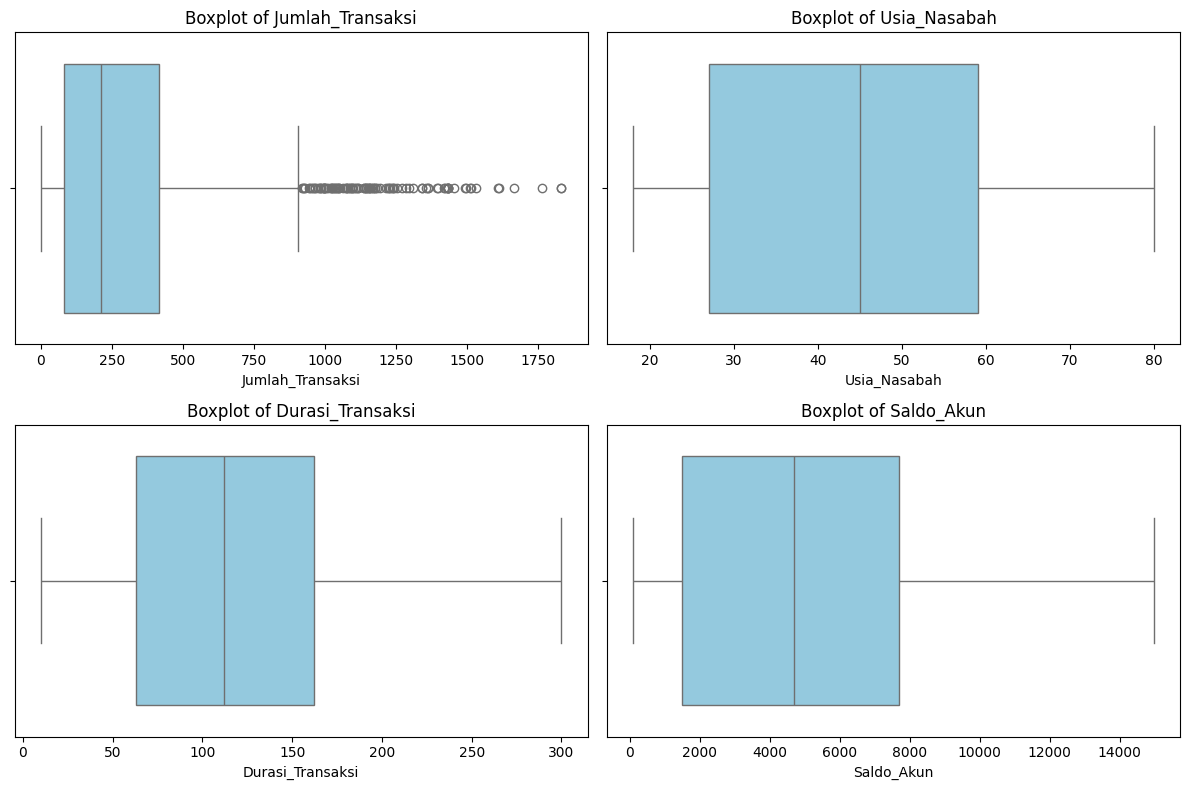

Hasil Deteksi Outlier menggunakan IQR:

--- Kolom: Jumlah_Transaksi ---
Batas Bawah: -417.55, Batas Atas: 913.93
Jumlah Outlier: 100 dari 2283 data valid
------------------------------
--- Kolom: Usia_Nasabah ---
Batas Bawah: -21.00, Batas Atas: 107.00
Jumlah Outlier: 0 dari 2283 data valid
------------------------------
--- Kolom: Durasi_Transaksi ---
Batas Bawah: -85.50, Batas Atas: 310.50
Jumlah Outlier: 0 dari 2283 data valid
------------------------------
--- Kolom: Saldo_Akun ---
Batas Bawah: -7822.28, Batas Atas: 16995.90
Jumlah Outlier: 0 dari 2283 data valid
------------------------------


In [98]:
numeric_cols = df_baru.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_baru[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Hasil Deteksi Outlier menggunakan IQR:\n")
for col in numeric_cols:
    outliers, lower, upper = find_outliers_iqr(df_baru, col)
    print(f"--- Kolom: {col} ---")
    print(f"Batas Bawah: {lower:.2f}, Batas Atas: {upper:.2f}")
    print(f"Jumlah Outlier: {len(outliers)} dari {df_baru[col].notna().sum()} data valid")
    print("-" * 30)

## **Mengatasi Outlier dengan Log Transfromasi**

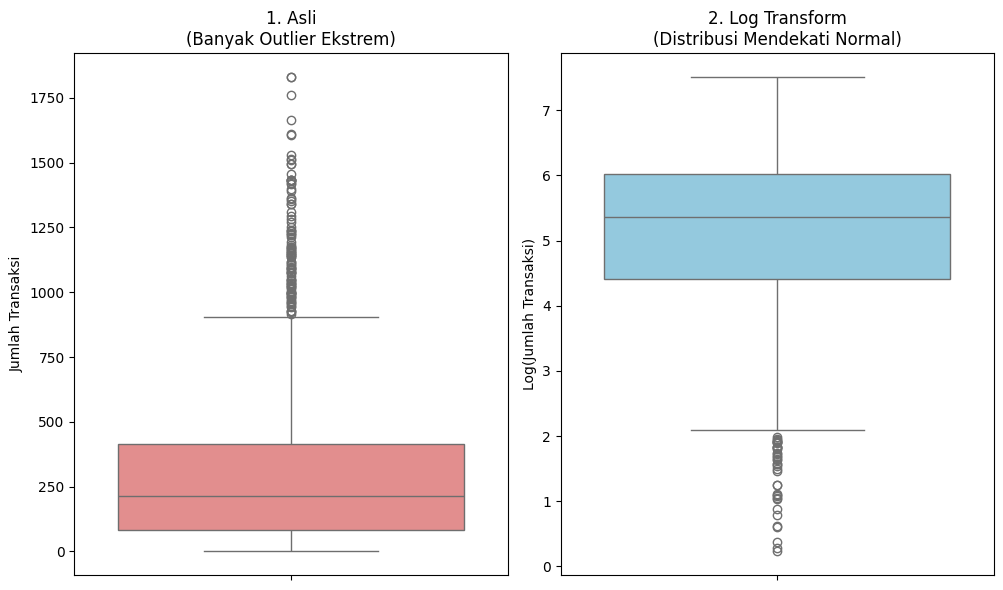

Text(0, 0.5, 'Frekuensi')

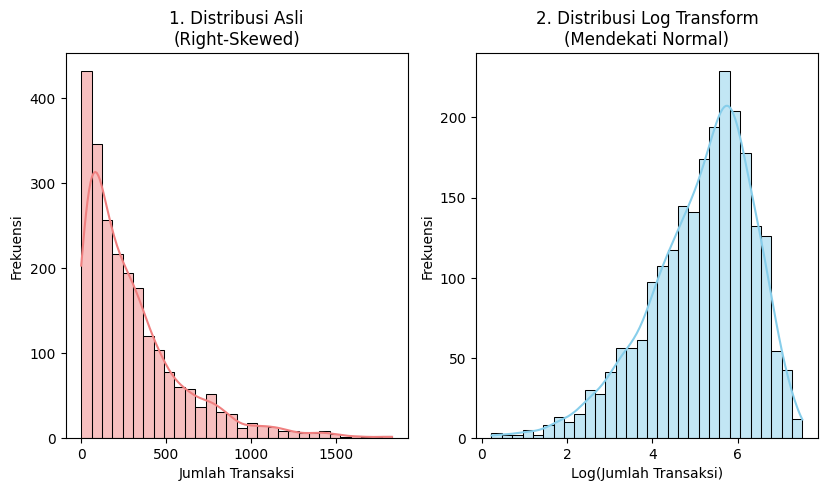

In [99]:
df_baru['Jumlah_Transaksi_Log'] = np.log1p(df_baru['Jumlah_Transaksi'])

plt.figure(figsize=(15, 6))

# Boxplot Data Asli
plt.subplot(1, 3, 1)
sns.boxplot(y=df_baru['Jumlah_Transaksi'], color='lightcoral')
plt.title('1. Asli\n(Banyak Outlier Ekstrem)')
plt.ylabel('Jumlah Transaksi')

# Boxplot Log Transform
plt.subplot(1, 3, 2)
sns.boxplot(y=df_baru['Jumlah_Transaksi_Log'], color='skyblue')
plt.title('2. Log Transform\n(Distribusi Mendekati Normal)')
plt.ylabel('Log(Jumlah Transaksi)')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))

# Histogram Data Asli
plt.subplot(1, 3, 1)
sns.histplot(df_baru['Jumlah_Transaksi'], bins=30, kde=True, color='lightcoral')
plt.title('1. Distribusi Asli\n(Right-Skewed)')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Frekuensi')

# Histogram Log Transform
plt.subplot(1, 3, 2)
sns.histplot(df_baru['Jumlah_Transaksi_Log'], bins=30, kde=True, color='skyblue')
plt.title('2. Distribusi Log Transform\n(Mendekati Normal)')
plt.xlabel('Log(Jumlah Transaksi)')
plt.ylabel('Frekuensi')

## **Melakukan Exploratory Data Analysis**

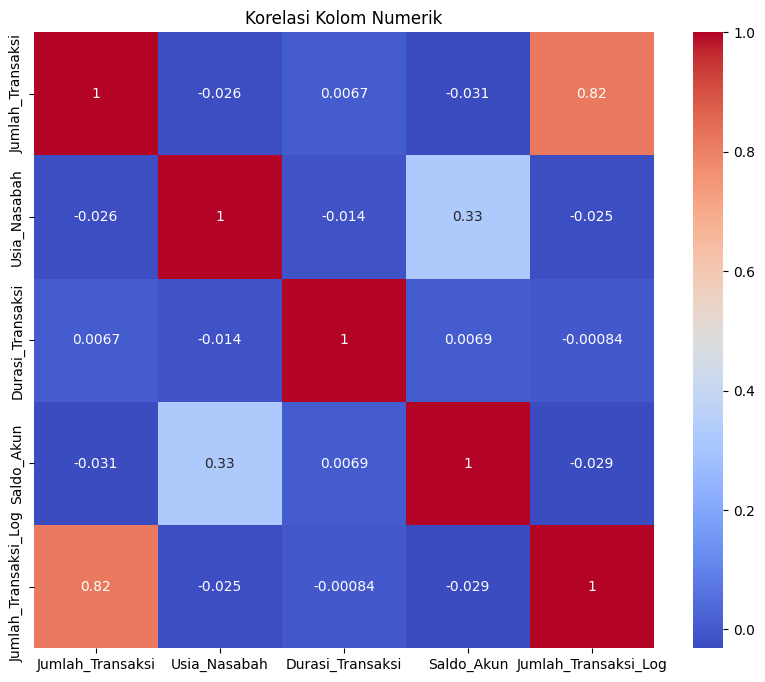

In [100]:
kolom_angka = df_baru.select_dtypes(include=['number']).columns
korelasi = df_baru[kolom_angka].corr()
plt.figure(figsize=(10,8))
sns.heatmap(korelasi, annot=True, cmap='coolwarm')
plt.title('Korelasi Kolom Numerik')
plt.show()

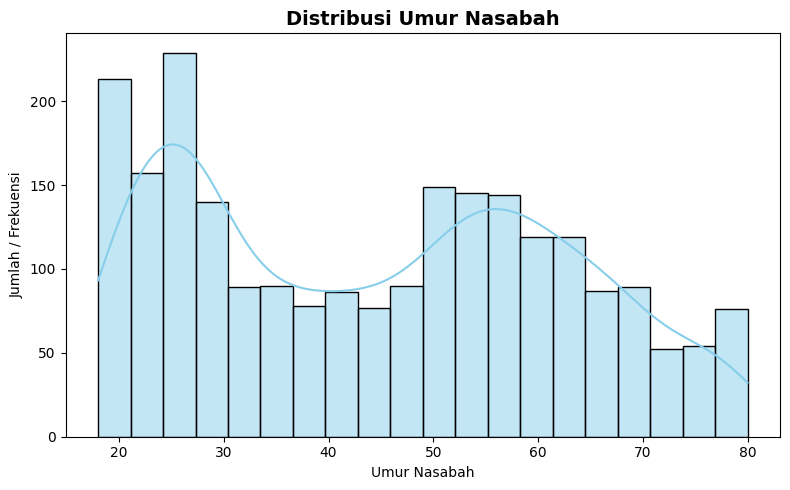

In [101]:
plt.figure(figsize=(8, 5))
sns.histplot(df_baru['Usia_Nasabah'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Umur Nasabah', fontsize=14, fontweight='bold')
plt.xlabel('Umur Nasabah')
plt.ylabel('Jumlah / Frekuensi')
plt.tight_layout()
plt.show()

/tmp/ipykernel_37983/2752476128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_baru, x='Kanal_Transaksi', palette='Set2', order=df_baru['Kanal_Transaksi'].value_counts().index)


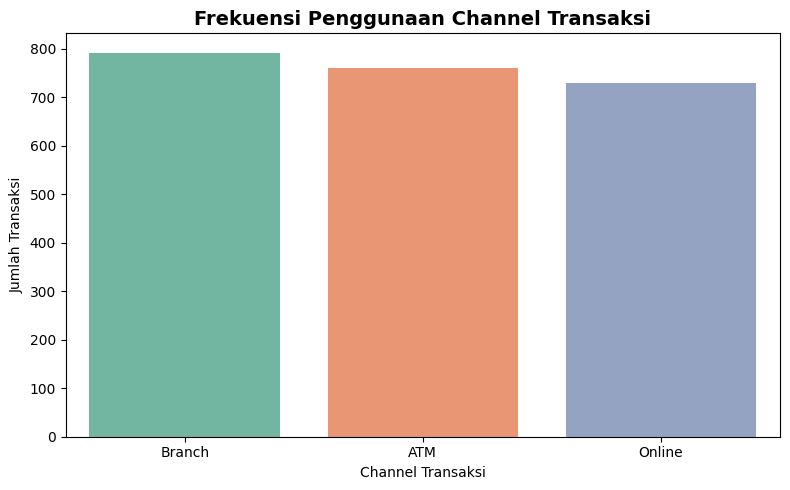

In [102]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_baru, x='Kanal_Transaksi', palette='Set2', order=df_baru['Kanal_Transaksi'].value_counts().index)
plt.title('Frekuensi Penggunaan Channel Transaksi', fontsize=14, fontweight='bold')
plt.xlabel('Channel Transaksi')
plt.ylabel('Jumlah Transaksi') # nominal transaksi
plt.tight_layout()
plt.show()

/tmp/ipykernel_37983/3474634427.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order=df_baru.groupby('Pekerjaan_Nasabah')['Saldo_Akun'].mean().sort_values(ascending=False).index)
/tmp/ipykernel_37983/3474634427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_baru, x='Pekerjaan_Nasabah', y='Saldo_Akun',


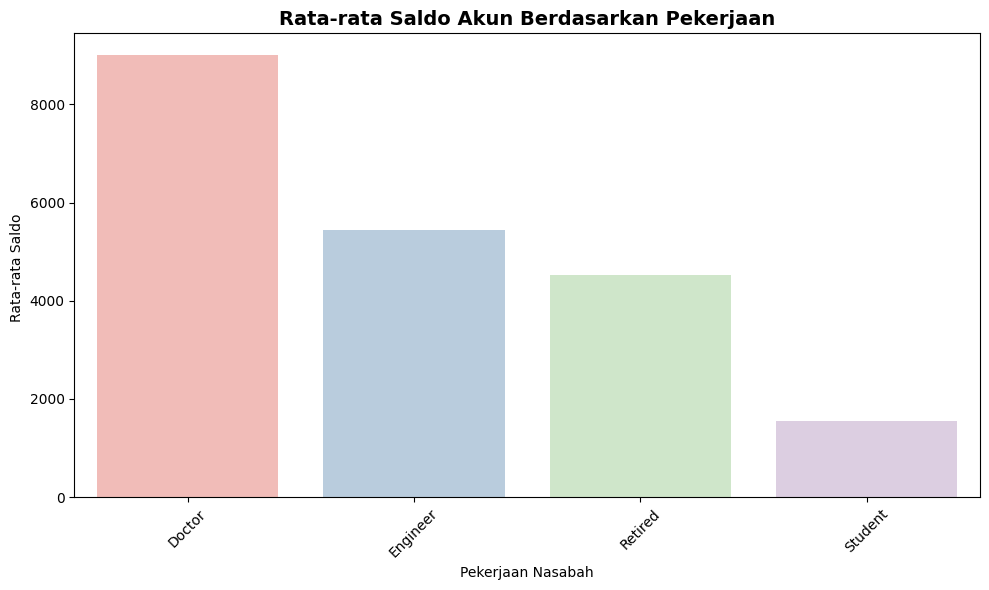

In [103]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_baru, x='Pekerjaan_Nasabah', y='Saldo_Akun',
            estimator='mean', errorbar=None, palette='Pastel1',
            order=df_baru.groupby('Pekerjaan_Nasabah')['Saldo_Akun'].mean().sort_values(ascending=False).index)
plt.title('Rata-rata Saldo Akun Berdasarkan Pekerjaan', fontsize=14, fontweight='bold')
plt.xlabel('Pekerjaan Nasabah')
plt.ylabel('Rata-rata Saldo ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

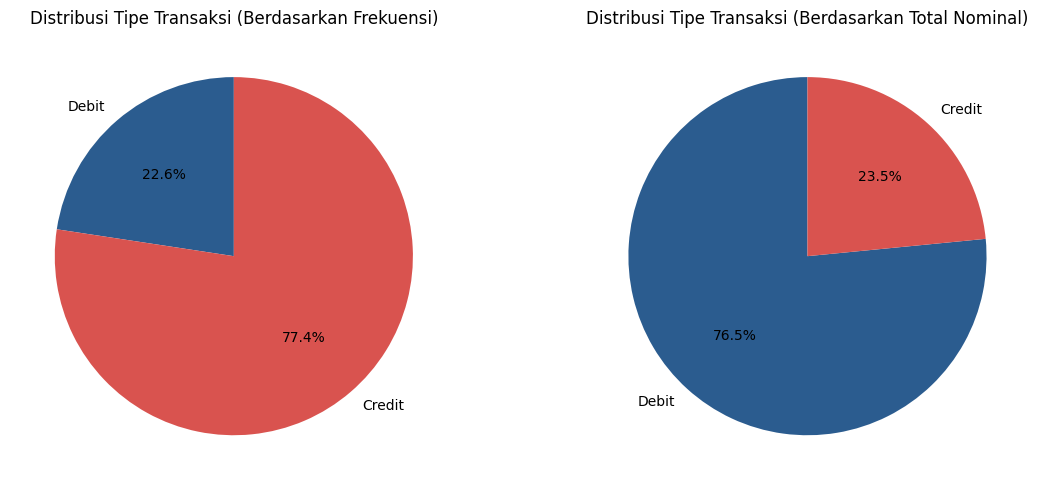

In [104]:
Jenis_credit = (df_baru['Jenis_Transaksi'] == 'Debit').sum()
Jenis_debit = (df_baru['Jenis_Transaksi'] == 'Credit').sum()
nominal_debit = df_baru[df_baru['Jenis_Transaksi'] == 'Debit']['Jumlah_Transaksi'].sum()
nominal_credit = df_baru[df_baru['Jenis_Transaksi'] == 'Credit']['Jumlah_Transaksi'].sum()

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.pie([Jenis_debit, Jenis_credit], labels=['Debit', 'Credit'], autopct='%1.1f%%', colors=['#2b5c8f', '#d9534f'], startangle=90)
plt.title('Distribusi Tipe Transaksi (Berdasarkan Frekuensi)')

plt.subplot(1, 2, 2)
plt.pie([nominal_debit, nominal_credit], labels=['Debit', 'Credit'], autopct='%1.1f%%', colors=['#2b5c8f', '#d9534f'], startangle=90)
plt.title('Distribusi Tipe Transaksi (Berdasarkan Total Nominal)')

plt.tight_layout()
plt.show()

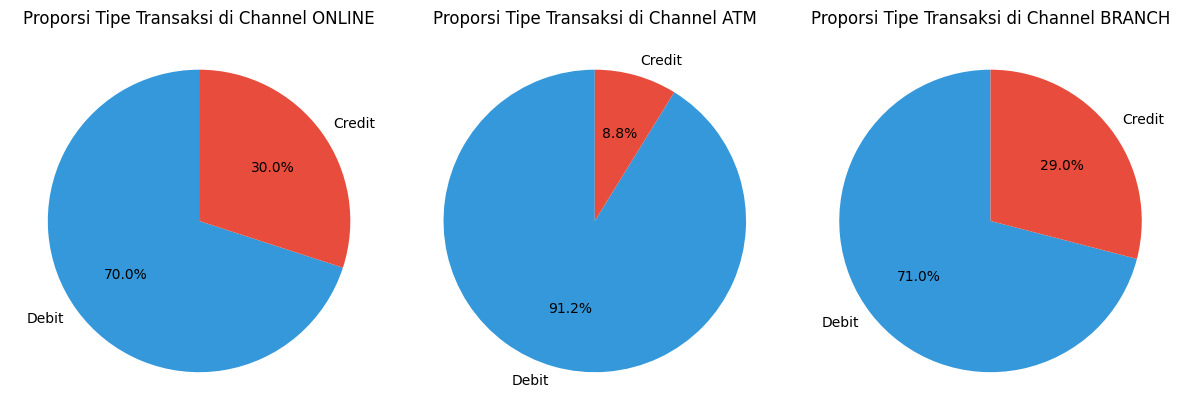

In [105]:
jumlah_debit_online = ((df_baru['Kanal_Transaksi'] == 'Online') & (df_baru['Jenis_Transaksi'] == 'Debit')).sum()
jumlah_credit_online = ((df_baru['Kanal_Transaksi'] == 'Online') & (df_baru['Jenis_Transaksi'] == 'Credit')).sum()

jumlah_debit_atm = ((df_baru['Kanal_Transaksi'] == 'ATM') & (df_baru['Jenis_Transaksi'] == 'Debit')).sum()
jumlah_credit_atm = ((df_baru['Kanal_Transaksi'] == 'ATM') & (df_baru['Jenis_Transaksi'] == 'Credit')).sum()

jumlah_debit_branch = ((df_baru['Kanal_Transaksi'] == 'Branch') & (df_baru['Jenis_Transaksi'] == 'Debit')).sum()
jumlah_credit_branch = ((df_baru['Kanal_Transaksi'] == 'Branch') & (df_baru['Jenis_Transaksi'] == 'Credit')).sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.pie([jumlah_debit_online, jumlah_credit_online],
        labels=['Debit', 'Credit'],
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90)
plt.title('Proporsi Tipe Transaksi di Channel ONLINE')

plt.subplot(1, 3, 2)
plt.pie([jumlah_debit_atm, jumlah_credit_atm],
        labels=['Debit', 'Credit'],
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90)
plt.title('Proporsi Tipe Transaksi di Channel ATM')

plt.subplot(1, 3, 3)
plt.pie([jumlah_debit_branch, jumlah_credit_branch],
        labels=['Debit', 'Credit'],
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90)
plt.title('Proporsi Tipe Transaksi di Channel BRANCH')

plt.tight_layout()
plt.show()

## **CLUSTERING**

In [106]:
fitur_segmentasi = ['Jumlah_Transaksi', 'Usia_Nasabah', 'Durasi_Transaksi', 'Saldo_Akun']
X = df_baru[fitur_segmentasi]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_baru['Kluster'] = kmeans.fit_predict(X_scaled)

pemetaan_segmen = {
    0: 'C0 - High Spender  ',
    1: 'C1 - Saver ',
    2: 'C2- Young & Active'
}
df_baru['Nama_Segmen'] = df_baru['Kluster'].map(pemetaan_segmen)

print("Jumlah Anggota per Segmen:")
print(df_baru['Nama_Segmen'].value_counts())

Jumlah Anggota per Segmen:
Nama_Segmen
C1 - Saver             1170
C2- Young & Active      805
C0 - High Spender       308
Name: count, dtype: int64


,Jumlah_Transaksi,Usia_Nasabah,Durasi_Transaksi,Saldo_Akun
Nama_Segmen,,,,
C0 - High Spender,872.644643,46.457792,116.655844,5253.450455
C1 - Saver,194.780231,55.511111,121.141880,7209.692043
C2- Young & Active,227.911118,27.880745,119.004969,1961.976248


/tmp/ipykernel_37983/2441148626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rata_rata_saldo, x='Nama_Segmen', y='Saldo_Akun', palette='Set2')


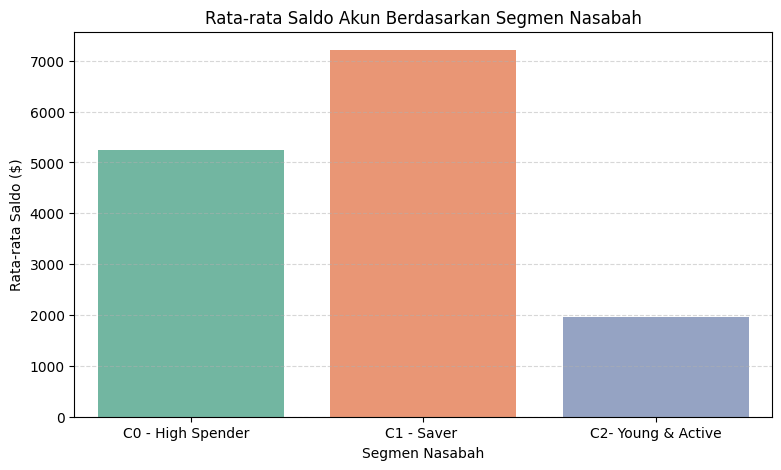

In [107]:
display(df_baru.groupby('Nama_Segmen')[fitur_segmentasi].mean())

plt.figure(figsize=(9, 5))
rata_rata_saldo = df_baru.groupby('Nama_Segmen')['Saldo_Akun'].mean().reset_index()

sns.barplot(data=rata_rata_saldo, x='Nama_Segmen', y='Saldo_Akun', palette='Set2')
plt.title('Rata-rata Saldo Akun Berdasarkan Segmen Nasabah')
plt.xlabel('Segmen Nasabah')
plt.ylabel('Rata-rata Saldo ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

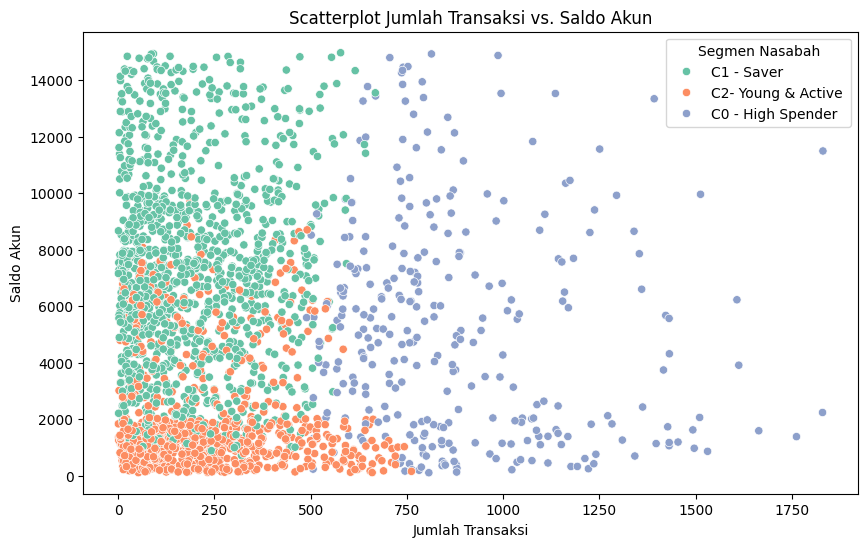

In [108]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_baru, x='Jumlah_Transaksi', y='Saldo_Akun', hue='Nama_Segmen', palette='Set2')
plt.title('Scatterplot Jumlah Transaksi vs. Saldo Akun')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Saldo Akun')
plt.legend(title='Segmen Nasabah', loc='upper right')

## **Export to CSV**

In [ ]:
df_baru.to_csv('hasil_segmentasi_nasabah.csv', index=False)
